In [6]:
# Q2

import numpy as np
from scipy.optimize import least_squares

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import get_body_barycentric, solar_system_ephemeris

from poliastro.twobody import Orbit
from poliastro.bodies import Sun


# raw data from the observation file 
RAW_DATA = [
    ("2024-07-31T02:24:00.00Z", 252.359367, 8.056822),
    ("2024-07-31T00:00:00.00Z", 252.285371, 8.098561),
    ("2024-07-28T02:24:00.00Z", 250.091267, 9.330564),
    ("2024-07-28T00:00:00.00Z", 250.013854, 9.373778),
    ("2024-07-25T02:24:00.00Z", 247.712908, 10.647547),
    ("2024-07-25T00:00:00.00Z", 247.631529, 10.692161),
    ("2024-07-22T02:24:00.00Z", 245.206933, 12.005103),
    ("2024-07-22T00:00:00.00Z", 245.120992, 12.051017),
    ("2024-07-19T02:24:00.00Z", 242.554808, 13.399564),
    ("2024-07-19T00:00:00.00Z", 242.463658, 13.446622),
    ("2024-07-18T02:24:00.00Z", 241.634917, 13.871689),
    ("2024-07-18T00:00:00.00Z", 241.541883, 13.919083),
    ("2024-07-17T02:24:00.00Z", 240.695829, 14.347042),
    ("2024-07-17T00:00:00.00Z", 240.600833, 14.394744),
    ("2024-07-16T02:24:00.00Z", 239.736750, 14.825328),
    ("2024-07-16T00:00:00.00Z", 239.639708, 14.873306),
    ("2024-07-15T02:24:00.00Z", 238.756850, 15.306208),
    ("2024-07-15T00:00:00.00Z", 238.657683, 15.354425),
    ("2024-07-14T02:24:00.00Z", 237.755283, 15.789308),
    ("2024-07-14T00:00:00.00Z", 237.653900, 15.837725),
    ("2024-07-13T02:24:00.00Z", 236.731171, 16.274222),
    ("2024-07-13T00:00:00.00Z", 236.627483, 16.322794),
    ("2024-07-12T02:24:00.00Z", 235.683612, 16.760494),
    ("2024-07-12T00:00:00.00Z", 235.577533, 16.809181),
    ("2024-07-11T02:24:00.00Z", 234.611700, 17.247639),
    ("2024-07-11T00:00:00.00Z", 234.503133, 17.296381),
    ("2024-07-10T02:24:00.00Z", 233.514492, 17.735111),
    ("2024-07-10T00:00:00.00Z", 233.403346, 17.783853),
    ("2024-07-09T02:24:00.00Z", 232.391046, 18.222325),
    ("2024-07-09T00:00:00.00Z", 232.277221, 18.271008),
    ("2024-07-08T02:24:00.00Z", 231.240400, 18.708647),
    ("2024-07-08T00:00:00.00Z", 231.123800, 18.757203),
    ("2024-07-07T02:24:00.00Z", 230.061592, 19.193386),
    ("2024-07-07T00:00:00.00Z", 229.942125, 19.241744),
    ("2024-07-06T02:24:00.00Z", 228.853658, 19.675797),
    ("2024-07-06T00:00:00.00Z", 228.731225, 19.723881),
    ("2024-07-05T02:24:00.00Z", 227.615642, 20.155086),
    ("2024-07-05T00:00:00.00Z", 227.490146, 20.202808),
    ("2024-07-04T02:24:00.00Z", 226.346592, 20.630397),
    ("2024-07-04T00:00:00.00Z", 226.217942, 20.677675),
    ("2024-07-03T02:24:00.00Z", 225.045588, 21.100822),
    ("2024-07-03T00:00:00.00Z", 224.913692, 21.147561),
    ("2024-07-02T02:24:00.00Z", 223.711737, 21.565408),
    ("2024-07-02T00:00:00.00Z", 223.576513, 21.611506),
    ("2024-07-01T02:24:00.00Z", 222.344200, 22.023136),
    ("2024-07-01T00:00:00.00Z", 222.205563, 22.068489),
    ("2024-06-30T02:24:00.00Z", 220.942200, 22.472942),
    ("2024-06-30T00:00:00.00Z", 220.800075, 22.517444),
    ("2024-06-29T02:24:00.00Z", 219.505037, 22.913711),
    ("2024-06-29T00:00:00.00Z", 219.359367, 22.957247),
    ("2024-06-28T02:24:00.00Z", 218.032129, 23.344278),
    ("2024-06-28T00:00:00.00Z", 217.882854, 23.386728),
    ("2024-06-27T02:24:00.00Z", 216.523000, 23.763425),
    ("2024-06-27T00:00:00.00Z", 216.370083, 23.804664),
    ("2024-06-26T02:24:00.00Z", 214.977329, 24.169886),
    ("2024-06-26T00:00:00.00Z", 214.820746, 24.209786),
    ("2024-06-25T02:24:00.00Z", 213.394954, 24.562350),
    ("2024-06-25T00:00:00.00Z", 213.234696, 24.600775),
    ("2024-06-24T02:24:00.00Z", 211.775904, 24.939461),
    ("2024-06-24T00:00:00.00Z", 211.611987, 24.976275),
    ("2024-06-23T02:24:00.00Z", 210.120412, 25.299822),
    ("2024-06-23T00:00:00.00Z", 209.952875, 25.334883),
    ("2024-06-22T02:24:00.00Z", 208.428933, 25.642003),
    ("2024-06-22T00:00:00.00Z", 208.257829, 25.675167),
    ("2024-06-21T02:24:00.00Z", 206.702163, 25.964550),
    ("2024-06-21T00:00:00.00Z", 206.527575, 25.995669),
    ("2024-06-20T02:24:00.00Z", 204.941033, 26.265997),
    ("2024-06-20T00:00:00.00Z", 204.763075, 26.294928),
    ("2024-06-19T02:24:00.00Z", 203.146750, 26.544889),
    ("2024-06-19T00:00:00.00Z", 202.965550, 26.571481),
    ("2024-06-18T02:24:00.00Z", 201.320767, 26.799781),
    ("2024-06-18T00:00:00.00Z", 201.136492, 26.823894),
    ("2024-06-17T02:24:00.00Z", 199.464817, 27.029281),
    ("2024-06-17T00:00:00.00Z", 199.277646, 27.050783),
    ("2024-06-16T02:24:00.00Z", 197.580883, 27.232058),
    ("2024-06-16T00:00:00.00Z", 197.391038, 27.250819),
    ("2024-06-15T02:24:00.00Z", 195.671229, 27.406869),
    ("2024-06-15T00:00:00.00Z", 195.478942, 27.422767),
    ("2024-06-14T02:24:00.00Z", 193.738350, 27.552569),
    ("2024-06-14T00:00:00.00Z", 193.543892, 27.565500),
    ("2024-06-13T02:24:00.00Z", 191.784996, 27.668150),
    ("2024-06-13T00:00:00.00Z", 191.588646, 27.678017),
    ("2024-06-12T02:24:00.00Z", 189.814125, 27.752747),
    ("2024-06-12T00:00:00.00Z", 189.616192, 27.759475),
    ("2024-06-11T02:24:00.00Z", 187.828883, 27.805656),
    ("2024-06-11T00:00:00.00Z", 187.629696, 27.809183),
    ("2024-06-10T02:24:00.00Z", 185.832592, 27.826358),
    ("2024-06-10T00:00:00.00Z", 185.632483, 27.826642),
    ("2024-06-09T02:24:00.00Z", 183.828679, 27.814522),
    ("2024-06-09T00:00:00.00Z", 183.628004, 27.811542),
    ("2024-06-08T02:24:00.00Z", 181.820671, 27.770025),
    ("2024-06-08T00:00:00.00Z", 181.619783, 27.763781),
    ("2024-06-07T02:24:00.00Z", 179.812129, 27.692947),
    ("2024-06-07T00:00:00.00Z", 179.611383, 27.683458),
    ("2024-06-06T02:24:00.00Z", 177.806604, 27.583594),
    ("2024-06-06T00:00:00.00Z", 177.606354, 27.570900),
    ("2024-06-05T02:24:00.00Z", 175.807604, 27.442472),
    ("2024-06-05T00:00:00.00Z", 175.608196, 27.426642)
]

def residuals(x, obs_times, obs_ra, obs_dec, earth_positions):
    """
    Calculates the difference between predicted RA/Dec and observed RA/Dec.
    """
    e, q, tp, om, w, inc = x
    
    # semi major axis from perihelion distance
    a = q / (1.0 - e)
    tp_time = Time(tp, format='mjd', scale='tdb')
    
    try:
        
        orbit_at_tp = Orbit.from_classical(
            Sun, a * u.AU, e * u.one, inc * u.deg, om * u.deg, w * u.deg, 0 * u.deg, epoch=tp_time
        )
        
        res = []
        for j, t in enumerate(obs_times):
            # time of flight (in days)
            tof = (t.mjd - tp_time.mjd) * u.day
            orbit_at_obs = orbit_at_tp.propagate(tof)
            
            r_ast = orbit_at_obs.r.to(u.km).value
            r_earth = earth_positions[j]
            
            # line of sight vector (Asteroid position minus Earth position)
            rho = r_ast - r_earth
            x_rho, y_rho, z_rho = rho
            dist = np.sqrt(x_rho**2 + y_rho**2 + z_rho**2)
            
            
            dec_calc = np.degrees(np.arcsin(z_rho / dist))
            ra_calc = np.degrees(np.arctan2(y_rho, x_rho)) % 360
            
          
            ra_diff = (ra_calc - obs_ra[j] + 180) % 360 - 180
            dec_diff = dec_calc - obs_dec[j]
            
            res.extend([ra_diff, dec_diff])
            
        return np.array(res)
    except Exception:
        # in case the orbit doesn't make sense
        return np.ones(len(obs_times) * 2) * 1e6

def main():
    

    obs_data = RAW_DATA
        
    
    indices = np.linspace(0, len(obs_data)-1, 15, dtype=int)
    sampled_obs = [obs_data[i] for i in indices]
    
    obs_times = Time([row[0] for row in sampled_obs], format='isot', scale='utc')
    obs_ra = np.array([row[1] for row in sampled_obs])
    obs_dec = np.array([row[2] for row in sampled_obs])
    
    # Earth heliocentric positions for the observation times
    earth_positions = []
    with solar_system_ephemeris.set('builtin'):
        for t in obs_times:
            earth = get_body_barycentric('earth', t)
            sun = get_body_barycentric('sun', t)
            r_heliocentric = (earth.xyz - sun.xyz).to(u.km).value
            earth_positions.append(r_heliocentric)
    earth_positions = np.array(earth_positions)

    # Initial guess for orbital elements
    x0 = [
        0.3906575,
        1.00537975,
        60440.598182003385,
        214.42379,
        359.96368,
        10.68883
    ]
    
    # bounds
    bounds = (
        [0.0, 0.5, 60000, 0, 0, 0], 
        [0.9, 2.0, 61000, 360, 360, 180]
    )

    # least squares method
    result = least_squares(
        residuals, 
        x0, 
        bounds=bounds, 
        args=(obs_times, obs_ra, obs_dec, earth_positions),
        loss='soft_l1' 
    )
    
    
    e_opt, q_opt, tp_opt, om_opt, w_opt, inc_opt = result.x
    a_opt = q_opt / (1.0 - e_opt)
    
    orbit_fitted = Orbit.from_classical(
        Sun, 
        a_opt * u.AU, 
        e_opt * u.one, 
        inc_opt * u.deg, 
        om_opt * u.deg, 
        w_opt * u.deg, 
        0 * u.deg, 
        epoch=Time(tp_opt, format='mjd', scale='tdb')
    )
    
    eval_epoch = Time(60522.0, format='mjd', scale='tdb')
    tof_eval = (eval_epoch.mjd - tp_opt) * u.day
    final_orbit = orbit_fitted.propagate(tof_eval)
   
    print(f"FINAL ORBITAL ELEMENTS (Epoch: {eval_epoch.mjd})")
    print("="*50)
    print(f"Eccentricity (e)    : {final_orbit.ecc.value:.7f}")
    print(f"Semi-Major Axis (a) : {final_orbit.a.to(u.AU).value:.7f} AU")
    print(f"Perihelion (q)      : {q_opt:.7f} AU")
    print(f"Time of Perihelion (tp)   : {tp_opt:.7f} days")
    print(f"Asc. Node (om)      : {final_orbit.raan.to(u.deg).value:.5f} deg")
    print(f"Arg. of Peri (w)    : {final_orbit.argp.to(u.deg).value:.5f} deg")
    print(f"Inclination (i)     : {final_orbit.inc.to(u.deg).value:.5f} deg")
    print(f"True Anomaly (nu)   : {final_orbit.nu.to(u.deg).value:.5f} deg")

if __name__ == "__main__":
    main()

FINAL ORBITAL ELEMENTS (Epoch: 60522.0)
Eccentricity (e)    : 0.9000000
Semi-Major Axis (a) : 11.9084321 AU
Perihelion (q)      : 1.1908432 AU
Time of Perihelion (tp)   : 60418.4328270 days
Asc. Node (om)      : 0.00000 deg
Arg. of Peri (w)    : 184.58413 deg
Inclination (i)     : 0.00000 deg
True Anomaly (nu)   : 77.24173 deg


In [7]:
# Q3

import numpy as np
from scipy.optimize import least_squares

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import get_body_barycentric, solar_system_ephemeris

from poliastro.twobody import Orbit
from poliastro.bodies import Sun

# raw data from the observation file 

RAW_DATA = [
    ("2024-07-31T02:24:00.00Z", 252.359367, 8.056822),
    ("2024-07-31T00:00:00.00Z", 252.285371, 8.098561),
    ("2024-07-28T02:24:00.00Z", 250.091267, 9.330564),
    ("2024-07-28T00:00:00.00Z", 250.013854, 9.373778),
    ("2024-07-25T02:24:00.00Z", 247.712908, 10.647547),
    ("2024-07-25T00:00:00.00Z", 247.631529, 10.692161),
    ("2024-07-22T02:24:00.00Z", 245.206933, 12.005103),
    ("2024-07-22T00:00:00.00Z", 245.120992, 12.051017),
    ("2024-07-19T02:24:00.00Z", 242.554808, 13.399564),
    ("2024-07-19T00:00:00.00Z", 242.463658, 13.446622),
    ("2024-07-18T02:24:00.00Z", 241.634917, 13.871689),
    ("2024-07-18T00:00:00.00Z", 241.541883, 13.919083),
    ("2024-07-17T02:24:00.00Z", 240.695829, 14.347042),
    ("2024-07-17T00:00:00.00Z", 240.600833, 14.394744),
    ("2024-07-16T02:24:00.00Z", 239.736750, 14.825328),
    ("2024-07-16T00:00:00.00Z", 239.639708, 14.873306),
    ("2024-07-15T02:24:00.00Z", 238.756850, 15.306208),
    ("2024-07-15T00:00:00.00Z", 238.657683, 15.354425),
    ("2024-07-14T02:24:00.00Z", 237.755283, 15.789308),
    ("2024-07-14T00:00:00.00Z", 237.653900, 15.837725),
    ("2024-07-13T02:24:00.00Z", 236.731171, 16.274222),
    ("2024-07-13T00:00:00.00Z", 236.627483, 16.322794),
    ("2024-07-12T02:24:00.00Z", 235.683612, 16.760494),
    ("2024-07-12T00:00:00.00Z", 235.577533, 16.809181),
    ("2024-07-11T02:24:00.00Z", 234.611700, 17.247639),
    ("2024-07-11T00:00:00.00Z", 234.503133, 17.296381),
    ("2024-07-10T02:24:00.00Z", 233.514492, 17.735111),
    ("2024-07-10T00:00:00.00Z", 233.403346, 17.783853),
    ("2024-07-09T02:24:00.00Z", 232.391046, 18.222325),
    ("2024-07-09T00:00:00.00Z", 232.277221, 18.271008),
    ("2024-07-08T02:24:00.00Z", 231.240400, 18.708647),
    ("2024-07-08T00:00:00.00Z", 231.123800, 18.757203),
    ("2024-07-07T02:24:00.00Z", 230.061592, 19.193386),
    ("2024-07-07T00:00:00.00Z", 229.942125, 19.241744),
    ("2024-07-06T02:24:00.00Z", 228.853658, 19.675797),
    ("2024-07-06T00:00:00.00Z", 228.731225, 19.723881),
    ("2024-07-05T02:24:00.00Z", 227.615642, 20.155086),
    ("2024-07-05T00:00:00.00Z", 227.490146, 20.202808),
    ("2024-07-04T02:24:00.00Z", 226.346592, 20.630397),
    ("2024-07-04T00:00:00.00Z", 226.217942, 20.677675),
    ("2024-07-03T02:24:00.00Z", 225.045588, 21.100822),
    ("2024-07-03T00:00:00.00Z", 224.913692, 21.147561),
    ("2024-07-02T02:24:00.00Z", 223.711737, 21.565408),
    ("2024-07-02T00:00:00.00Z", 223.576513, 21.611506),
    ("2024-07-01T02:24:00.00Z", 222.344200, 22.023136),
    ("2024-07-01T00:00:00.00Z", 222.205563, 22.068489),
    ("2024-06-30T02:24:00.00Z", 220.942200, 22.472942),
    ("2024-06-30T00:00:00.00Z", 220.800075, 22.517444),
    ("2024-06-29T02:24:00.00Z", 219.505037, 22.913711),
    ("2024-06-29T00:00:00.00Z", 219.359367, 22.957247),
    ("2024-06-28T02:24:00.00Z", 218.032129, 23.344278),
    ("2024-06-28T00:00:00.00Z", 217.882854, 23.386728),
    ("2024-06-27T02:24:00.00Z", 216.523000, 23.763425),
    ("2024-06-27T00:00:00.00Z", 216.370083, 23.804664),
    ("2024-06-26T02:24:00.00Z", 214.977329, 24.169886),
    ("2024-06-26T00:00:00.00Z", 214.820746, 24.209786),
    ("2024-06-25T02:24:00.00Z", 213.394954, 24.562350),
    ("2024-06-25T00:00:00.00Z", 213.234696, 24.600775),
    ("2024-06-24T02:24:00.00Z", 211.775904, 24.939461),
    ("2024-06-24T00:00:00.00Z", 211.611987, 24.976275),
    ("2024-06-23T02:24:00.00Z", 210.120412, 25.299822),
    ("2024-06-23T00:00:00.00Z", 209.952875, 25.334883),
    ("2024-06-22T02:24:00.00Z", 208.428933, 25.642003),
    ("2024-06-22T00:00:00.00Z", 208.257829, 25.675167),
    ("2024-06-21T02:24:00.00Z", 206.702163, 25.964550),
    ("2024-06-21T00:00:00.00Z", 206.527575, 25.995669),
    ("2024-06-20T02:24:00.00Z", 204.941033, 26.265997),
    ("2024-06-20T00:00:00.00Z", 204.763075, 26.294928),
    ("2024-06-19T02:24:00.00Z", 203.146750, 26.544889),
    ("2024-06-19T00:00:00.00Z", 202.965550, 26.571481),
    ("2024-06-18T02:24:00.00Z", 201.320767, 26.799781),
    ("2024-06-18T00:00:00.00Z", 201.136492, 26.823894),
    ("2024-06-17T02:24:00.00Z", 199.464817, 27.029281),
    ("2024-06-17T00:00:00.00Z", 199.277646, 27.050783),
    ("2024-06-16T02:24:00.00Z", 197.580883, 27.232058),
    ("2024-06-16T00:00:00.00Z", 197.391038, 27.250819),
    ("2024-06-15T02:24:00.00Z", 195.671229, 27.406869),
    ("2024-06-15T00:00:00.00Z", 195.478942, 27.422767),
    ("2024-06-14T02:24:00.00Z", 193.738350, 27.552569),
    ("2024-06-14T00:00:00.00Z", 193.543892, 27.565500),
    ("2024-06-13T02:24:00.00Z", 191.784996, 27.668150),
    ("2024-06-13T00:00:00.00Z", 191.588646, 27.678017),
    ("2024-06-12T02:24:00.00Z", 189.814125, 27.752747),
    ("2024-06-12T00:00:00.00Z", 189.616192, 27.759475),
    ("2024-06-11T02:24:00.00Z", 187.828883, 27.805656),
    ("2024-06-11T00:00:00.00Z", 187.629696, 27.809183),
    ("2024-06-10T02:24:00.00Z", 185.832592, 27.826358),
    ("2024-06-10T00:00:00.00Z", 185.632483, 27.826642),
    ("2024-06-09T02:24:00.00Z", 183.828679, 27.814522),
    ("2024-06-09T00:00:00.00Z", 183.628004, 27.811542),
    ("2024-06-08T02:24:00.00Z", 181.820671, 27.770025),
    ("2024-06-08T00:00:00.00Z", 181.619783, 27.763781),
    ("2024-06-07T02:24:00.00Z", 179.812129, 27.692947),
    ("2024-06-07T00:00:00.00Z", 179.611383, 27.683458),
    ("2024-06-06T02:24:00.00Z", 177.806604, 27.583594),
    ("2024-06-06T00:00:00.00Z", 177.606354, 27.570900),
    ("2024-06-05T02:24:00.00Z", 175.807604, 27.442472),
    ("2024-06-05T00:00:00.00Z", 175.608196, 27.426642)
]

def residuals(x, obs_times, obs_ra, obs_dec, earth_positions):
    """
    Calculates the difference between predicted RA/Dec and observed RA/Dec.
    """
    e, q, tp, om, w, inc = x
    
    # semi major axis from perihelion distance
    a = q / (1.0 - e)
    tp_time = Time(tp, format='mjd', scale='tdb')
    
    try:
        
        orbit_at_tp = Orbit.from_classical(
            Sun, a * u.AU, e * u.one, inc * u.deg, om * u.deg, w * u.deg, 0 * u.deg, epoch=tp_time
        )
        
        res = []
        for j, t in enumerate(obs_times):
            # time of flight (days)
            tof = (t.mjd - tp_time.mjd) * u.day
            orbit_at_obs = orbit_at_tp.propagate(tof)
            
            r_ast = orbit_at_obs.r.to(u.km).value
            r_earth = earth_positions[j]
            
            # Line of sight vector (Asteroid position minus Earth position)
            rho = r_ast - r_earth
            x_rho, y_rho, z_rho = rho
            dist = np.sqrt(x_rho**2 + y_rho**2 + z_rho**2)
            
            
            dec_calc = np.degrees(np.arcsin(z_rho / dist))
            ra_calc = np.degrees(np.arctan2(y_rho, x_rho)) % 360
            
          
            ra_diff = (ra_calc - obs_ra[j] + 180) % 360 - 180
            dec_diff = dec_calc - obs_dec[j]
            
            res.extend([ra_diff, dec_diff])
            
        return np.array(res)
    except Exception:
        # in case the orbit doesn't make sense
        return np.ones(len(obs_times) * 2) * 1e6

def main():
    obs_data = RAW_DATA

    
    # process all observations
    obs_times = Time([row[0] for row in obs_data], format='isot', scale='utc')
    obs_ra = np.array([row[1] for row in obs_data])
    obs_dec = np.array([row[2] for row in obs_data])
    
    # Earth heliocentric positions for the observation times

    earth_positions = []
    with solar_system_ephemeris.set('builtin'):
        for t in obs_times:
            earth = get_body_barycentric('earth', t)
            sun = get_body_barycentric('sun', t)
            r_heliocentric = (earth.xyz - sun.xyz).to(u.km).value
            earth_positions.append(r_heliocentric)
    earth_positions = np.array(earth_positions)

    # initial guess
    x0 = [
        0.3906575,
        1.00537975,
        60440.598182003385,
        214.42379,
        359.96368,
        10.68883
    ]
    
    bounds = (
        [0.0, 0.5, 60000, 0, 0, 0], 
        [0.9, 2.0, 61000, 360, 360, 180]
    )

    
    # least squares method
    
    result = least_squares(
        residuals, 
        x0, 
        bounds=bounds, 
        args=(obs_times, obs_ra, obs_dec, earth_positions),
        loss='linear', 
        x_scale='jac' 
    )
    

    e_opt, q_opt, tp_opt, om_opt, w_opt, inc_opt = result.x
    a_opt = q_opt / (1.0 - e_opt)
    
    orbit_fitted = Orbit.from_classical(
        Sun, 
        a_opt * u.AU, 
        e_opt * u.one, 
        inc_opt * u.deg, 
        om_opt * u.deg, 
        w_opt * u.deg, 
        0 * u.deg, 
        epoch=Time(tp_opt, format='mjd', scale='tdb')
    )
    
    eval_epoch = Time(60522.0, format='mjd', scale='tdb')
    tof_eval = (eval_epoch.mjd - tp_opt) * u.day
    final_orbit = orbit_fitted.propagate(tof_eval)

    # calculate the covariance matrix using the jacobian
    J = result.jac 
    
    # find the mean squared error using the degrees of freedom
    dof = len(result.fun) - len(x0) 
    mse = np.sum(result.fun**2) / dof
    
    cov_matrix = np.linalg.pinv(J.T @ J) * mse
    

    print(f"BEST FIT ORBITAL ELEMENTS (Epoch: {eval_epoch.mjd})")
    print("="*60)
    print(f"Eccentricity (e)    : {final_orbit.ecc.value:.7f}")
    print(f"Semi-Major Axis (a) : {final_orbit.a.to(u.AU).value:.7f} AU")
    print(f"Perihelion (q)      : {q_opt:.7f} AU")
    print(f"Time of Perihelion (tp)   : {tp_opt:.7f} days")
    print(f"Asc. Node (om)      : {final_orbit.raan.to(u.deg).value:.5f} deg")
    print(f"Arg. of Peri (w)    : {final_orbit.argp.to(u.deg).value:.5f} deg")
    print(f"Inclination (i)     : {final_orbit.inc.to(u.deg).value:.5f} deg")
    print(f"True Anomaly (nu)   : {final_orbit.nu.to(u.deg).value:.5f} deg")
    
    print("\n" + "="*60)
    print("6x6 COVARIANCE MATRIX")
    print("Parameters: [e, q, tp, om, w, inc]")
    print("="*60)
    
    # formatting
    np.set_printoptions(precision=4, suppress=False, formatter={'float': '{: 0.4e}'.format}, linewidth=120)
    print(cov_matrix)


if __name__ == "__main__":
    main()

BEST FIT ORBITAL ELEMENTS (Epoch: 60522.0)
Eccentricity (e)    : 0.3906272
Semi-Major Axis (a) : 1.6498284 AU
Perihelion (q)      : 1.0053606 AU
Time of Perihelion (tp)   : 60440.5930590 days
Asc. Node (om)      : 337.28562 deg
Arg. of Peri (w)    : 235.85780 deg
Inclination (i)     : 15.75745 deg
True Anomaly (nu)   : 78.17112 deg

6x6 COVARIANCE MATRIX
Parameters: [e, q, tp, om, w, inc]
[[ 1.8877e-09  1.7168e-10  5.9020e-08 -5.6104e-08  7.4935e-08 -2.2589e-08]
 [ 1.7168e-10  1.5994e-11  5.4620e-09 -5.0378e-09  6.8692e-09 -2.0547e-09]
 [ 5.9020e-08  5.4620e-09  1.8702e-06 -1.7365e-06  2.3565e-06 -7.0616e-07]
 [-5.6104e-08 -5.0378e-09 -1.7365e-06  1.6861e-06 -2.2235e-06  6.7108e-07]
 [ 7.4935e-08  6.8692e-09  2.3565e-06 -2.2235e-06  2.9880e-06 -8.9629e-07]
 [-2.2589e-08 -2.0547e-09 -7.0616e-07  6.7108e-07 -8.9629e-07  2.7041e-07]]


/var/folders/28/3ln_7bw93p3gg0_59nqmp9pc0000gn/T/ipykernel_21083/3970558043.py:218: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  earth_circle = plt.Circle((0, 0), R_earth, color='dodgerblue', alpha=0.4, linewidth=2, edgecolor='navy', label='Earth (6,371 km radius)')


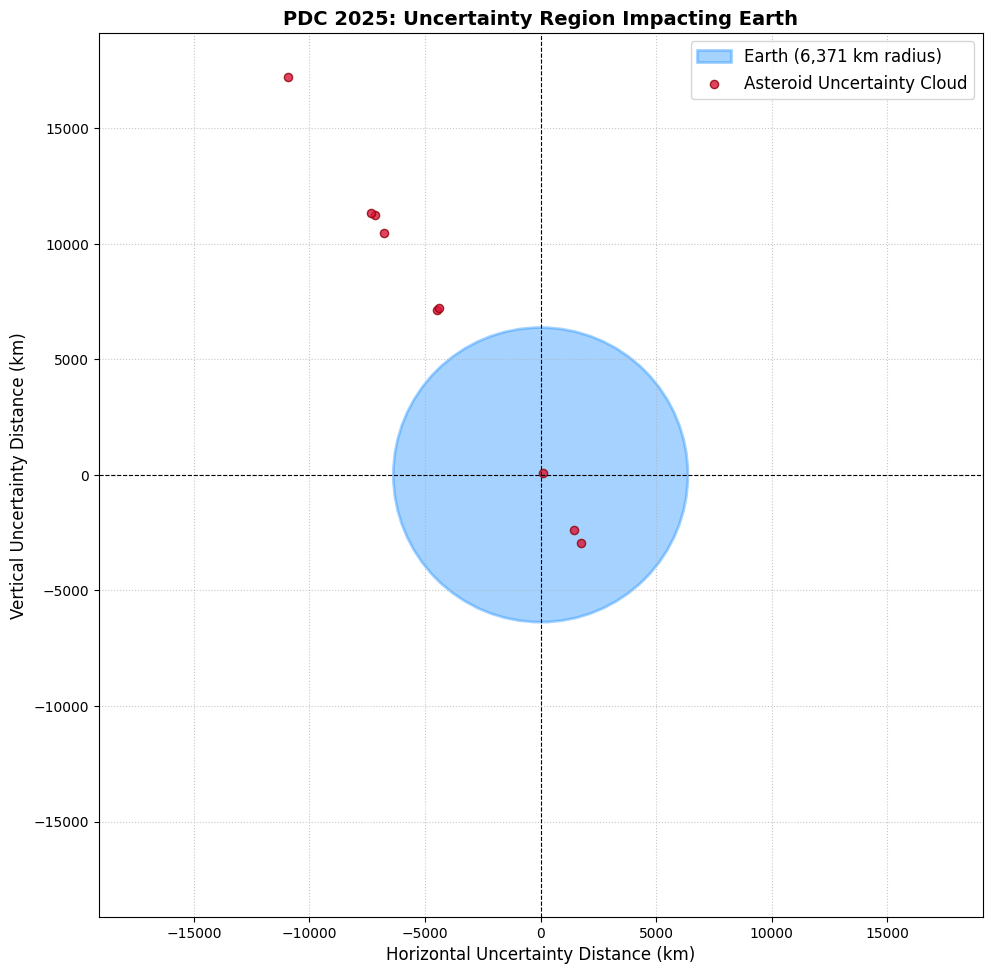

In [8]:
#Q4

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from astropy.time import Time
from astropy import units as u
from astropy.coordinates import get_body_barycentric, solar_system_ephemeris

from poliastro.twobody import Orbit
from poliastro.bodies import Sun

# raw data
RAW_DATA = [
    ("2024-07-31T02:24:00.00Z", 252.359367, 8.056822),
    ("2024-07-31T00:00:00.00Z", 252.285371, 8.098561),
    ("2024-07-28T02:24:00.00Z", 250.091267, 9.330564),
    ("2024-07-28T00:00:00.00Z", 250.013854, 9.373778),
    ("2024-07-25T02:24:00.00Z", 247.712908, 10.647547),
    ("2024-07-25T00:00:00.00Z", 247.631529, 10.692161),
    ("2024-07-22T02:24:00.00Z", 245.206933, 12.005103),
    ("2024-07-22T00:00:00.00Z", 245.120992, 12.051017),
    ("2024-07-19T02:24:00.00Z", 242.554808, 13.399564),
    ("2024-07-19T00:00:00.00Z", 242.463658, 13.446622),
    ("2024-07-18T02:24:00.00Z", 241.634917, 13.871689),
    ("2024-07-18T00:00:00.00Z", 241.541883, 13.919083),
    ("2024-07-17T02:24:00.00Z", 240.695829, 14.347042),
    ("2024-07-17T00:00:00.00Z", 240.600833, 14.394744),
    ("2024-07-16T02:24:00.00Z", 239.736750, 14.825328),
    ("2024-07-16T00:00:00.00Z", 239.639708, 14.873306),
    ("2024-07-15T02:24:00.00Z", 238.756850, 15.306208),
    ("2024-07-15T00:00:00.00Z", 238.657683, 15.354425),
    ("2024-07-14T02:24:00.00Z", 237.755283, 15.789308),
    ("2024-07-14T00:00:00.00Z", 237.653900, 15.837725),
    ("2024-07-13T02:24:00.00Z", 236.731171, 16.274222),
    ("2024-07-13T00:00:00.00Z", 236.627483, 16.322794),
    ("2024-07-12T02:24:00.00Z", 235.683612, 16.760494),
    ("2024-07-12T00:00:00.00Z", 235.577533, 16.809181),
    ("2024-07-11T02:24:00.00Z", 234.611700, 17.247639),
    ("2024-07-11T00:00:00.00Z", 234.503133, 17.296381),
    ("2024-07-10T02:24:00.00Z", 233.514492, 17.735111),
    ("2024-07-10T00:00:00.00Z", 233.403346, 17.783853),
    ("2024-07-09T02:24:00.00Z", 232.391046, 18.222325),
    ("2024-07-09T00:00:00.00Z", 232.277221, 18.271008),
    ("2024-07-08T02:24:00.00Z", 231.240400, 18.708647),
    ("2024-07-08T00:00:00.00Z", 231.123800, 18.757203),
    ("2024-07-07T02:24:00.00Z", 230.061592, 19.193386),
    ("2024-07-07T00:00:00.00Z", 229.942125, 19.241744),
    ("2024-07-06T02:24:00.00Z", 228.853658, 19.675797),
    ("2024-07-06T00:00:00.00Z", 228.731225, 19.723881),
    ("2024-07-05T02:24:00.00Z", 227.615642, 20.155086),
    ("2024-07-05T00:00:00.00Z", 227.490146, 20.202808),
    ("2024-07-04T02:24:00.00Z", 226.346592, 20.630397),
    ("2024-07-04T00:00:00.00Z", 226.217942, 20.677675),
    ("2024-07-03T02:24:00.00Z", 225.045588, 21.100822),
    ("2024-07-03T00:00:00.00Z", 224.913692, 21.147561),
    ("2024-07-02T02:24:00.00Z", 223.711737, 21.565408),
    ("2024-07-02T00:00:00.00Z", 223.576513, 21.611506),
    ("2024-07-01T02:24:00.00Z", 222.344200, 22.023136),
    ("2024-07-01T00:00:00.00Z", 222.205563, 22.068489),
    ("2024-06-30T02:24:00.00Z", 220.942200, 22.472942),
    ("2024-06-30T00:00:00.00Z", 220.800075, 22.517444),
    ("2024-06-29T02:24:00.00Z", 219.505037, 22.913711),
    ("2024-06-29T00:00:00.00Z", 219.359367, 22.957247),
    ("2024-06-28T02:24:00.00Z", 218.032129, 23.344278),
    ("2024-06-28T00:00:00.00Z", 217.882854, 23.386728),
    ("2024-06-27T02:24:00.00Z", 216.523000, 23.763425),
    ("2024-06-27T00:00:00.00Z", 216.370083, 23.804664),
    ("2024-06-26T02:24:00.00Z", 214.977329, 24.169886),
    ("2024-06-26T00:00:00.00Z", 214.820746, 24.209786),
    ("2024-06-25T02:24:00.00Z", 213.394954, 24.562350),
    ("2024-06-25T00:00:00.00Z", 213.234696, 24.600775),
    ("2024-06-24T02:24:00.00Z", 211.775904, 24.939461),
    ("2024-06-24T00:00:00.00Z", 211.611987, 24.976275),
    ("2024-06-23T02:24:00.00Z", 210.120412, 25.299822),
    ("2024-06-23T00:00:00.00Z", 209.952875, 25.334883),
    ("2024-06-22T02:24:00.00Z", 208.428933, 25.642003),
    ("2024-06-22T00:00:00.00Z", 208.257829, 25.675167),
    ("2024-06-21T02:24:00.00Z", 206.702163, 25.964550),
    ("2024-06-21T00:00:00.00Z", 206.527575, 25.995669),
    ("2024-06-20T02:24:00.00Z", 204.941033, 26.265997),
    ("2024-06-20T00:00:00.00Z", 204.763075, 26.294928),
    ("2024-06-19T02:24:00.00Z", 203.146750, 26.544889),
    ("2024-06-19T00:00:00.00Z", 202.965550, 26.571481),
    ("2024-06-18T02:24:00.00Z", 201.320767, 26.799781),
    ("2024-06-18T00:00:00.00Z", 201.136492, 26.823894),
    ("2024-06-17T02:24:00.00Z", 199.464817, 27.029281),
    ("2024-06-17T00:00:00.00Z", 199.277646, 27.050783),
    ("2024-06-16T02:24:00.00Z", 197.580883, 27.232058),
    ("2024-06-16T00:00:00.00Z", 197.391038, 27.250819),
    ("2024-06-15T02:24:00.00Z", 195.671229, 27.406869),
    ("2024-06-15T00:00:00.00Z", 195.478942, 27.422767),
    ("2024-06-14T02:24:00.00Z", 193.738350, 27.552569),
    ("2024-06-14T00:00:00.00Z", 193.543892, 27.565500),
    ("2024-06-13T02:24:00.00Z", 191.784996, 27.668150),
    ("2024-06-13T00:00:00.00Z", 191.588646, 27.678017),
    ("2024-06-12T02:24:00.00Z", 189.814125, 27.752747),
    ("2024-06-12T00:00:00.00Z", 189.616192, 27.759475),
    ("2024-06-11T02:24:00.00Z", 187.828883, 27.805656),
    ("2024-06-11T00:00:00.00Z", 187.629696, 27.809183),
    ("2024-06-10T02:24:00.00Z", 185.832592, 27.826358),
    ("2024-06-10T00:00:00.00Z", 185.632483, 27.826642),
    ("2024-06-09T02:24:00.00Z", 183.828679, 27.814522),
    ("2024-06-09T00:00:00.00Z", 183.628004, 27.811542),
    ("2024-06-08T02:24:00.00Z", 181.820671, 27.770025),
    ("2024-06-08T00:00:00.00Z", 181.619783, 27.763781),
    ("2024-06-07T02:24:00.00Z", 179.812129, 27.692947),
    ("2024-06-07T00:00:00.00Z", 179.611383, 27.683458),
    ("2024-06-06T02:24:00.00Z", 177.806604, 27.583594),
    ("2024-06-06T00:00:00.00Z", 177.606354, 27.570900),
    ("2024-06-05T02:24:00.00Z", 175.807604, 27.442472),
    ("2024-06-05T00:00:00.00Z", 175.608196, 27.426642)
]

def residuals(x, obs_times, obs_ra, obs_dec, earth_positions):
    e, q, tp, om, w, inc = x
    a = q / (1.0 - e)
    tp_time = Time(tp, format='mjd', scale='tdb')
    
    try:
        orbit_at_tp = Orbit.from_classical(Sun, a * u.AU, e * u.one, inc * u.deg, om * u.deg, w * u.deg, 0 * u.deg, epoch=tp_time)
        res = []
        for j, t in enumerate(obs_times):
            tof = (t.mjd - tp_time.mjd) * u.day
            r_ast = orbit_at_tp.propagate(tof).r.to(u.km).value
            
            rho = r_ast - earth_positions[j]
            x_rho, y_rho, z_rho = rho
            dist = np.sqrt(x_rho**2 + y_rho**2 + z_rho**2)
            
            dec_calc = np.degrees(np.arcsin(z_rho / dist))
            ra_calc = np.degrees(np.arctan2(y_rho, x_rho)) % 360
            
            res.extend([(ra_calc - obs_ra[j] + 180) % 360 - 180, dec_calc - obs_dec[j]])
        return np.array(res)
    except Exception:
        return np.ones(len(obs_times) * 2) * 1e6

def main():
   
    
    obs_times = Time([row[0] for row in RAW_DATA], format='isot', scale='utc')
    obs_ra = np.array([row[1] for row in RAW_DATA])
    obs_dec = np.array([row[2] for row in RAW_DATA])
    
    earth_positions = []
    with solar_system_ephemeris.set('builtin'):
        for t in obs_times:
            earth_positions.append((get_body_barycentric('earth', t).xyz - get_body_barycentric('sun', t).xyz).to(u.km).value)
    earth_positions = np.array(earth_positions)

    x0 = [0.3906575, 1.00537975, 60440.598182003385, 214.42379, 359.96368, 10.68883]
    bounds = ([0.0, 0.5, 60000, 0, 0, 0], [0.9, 2.0, 61000, 360, 360, 180])

    result = least_squares(residuals, x0, bounds=bounds, args=(obs_times, obs_ra, obs_dec, earth_positions), loss='linear', x_scale='jac')
    x_opt = result.x
    
    J = result.jac 
    mse = np.sum(result.fun**2) / (len(result.fun) - len(x0))
    cov_matrix = np.linalg.pinv(J.T @ J) * mse
    
    a_opt = x_opt[1] / (1.0 - x_opt[0])
    orbit_fitted = Orbit.from_classical(Sun, a_opt * u.AU, x_opt[0] * u.one, x_opt[5] * u.deg, x_opt[3] * u.deg, x_opt[4] * u.deg, 0 * u.deg, epoch=Time(x_opt[2], format='mjd', scale='tdb'))

    
    sweep_start = Time("2041-04-15T00:00:00", scale='utc')
    sweep_times = sweep_start + np.arange(0, 20, 0.25) * u.day
    
    min_dist = np.inf
    impact_date = sweep_start
    
    with solar_system_ephemeris.set('builtin'):
        for t in sweep_times:
            tof = (t.mjd - x_opt[2]) * u.day
            r_ast = orbit_fitted.propagate(tof).r.to(u.km).value
            r_earth = (get_body_barycentric('earth', t).xyz - get_body_barycentric('sun', t).xyz).to(u.km).value
            dist = np.linalg.norm(r_ast - r_earth)
            
            if dist < min_dist:
                min_dist = dist
                impact_date = t
                

    
    np.random.seed(42)
    samples = np.random.multivariate_normal(x_opt, cov_matrix, size=500)
    
    with solar_system_ephemeris.set('builtin'):
        earth_impact_pos = (get_body_barycentric('earth', impact_date).xyz - get_body_barycentric('sun', impact_date).xyz).to(u.km).value
    
    # find asteroid position
    pos_nom = orbit_fitted.propagate((impact_date.mjd - x_opt[2]) * u.day).r.to(u.km).value
    
    cloud_x = []
    cloud_y = []

    for i, s in enumerate(samples):
        e_k, q_k, tp_k, om_k, w_k, inc_k = s
        if e_k >= 1.0 or e_k <= 0.0 or q_k <= 0: continue
            
        orb_k = Orbit.from_classical(Sun, (q_k/(1-e_k)) * u.AU, e_k * u.one, inc_k * u.deg, om_k * u.deg, w_k * u.deg, 0 * u.deg, epoch=Time(tp_k, format='mjd', scale='tdb'))
        
        tof_k = (impact_date.mjd - tp_k) * u.day
        pos_k = orb_k.propagate(tof_k).r.to(u.km).value
        
        dispersion = pos_k - pos_nom
        
        cloud_x.append(dispersion[0])
        cloud_y.append(dispersion[1])

    
    R_earth = 6371.0 
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # plot Earth at the center
    earth_circle = plt.Circle((0, 0), R_earth, color='dodgerblue', alpha=0.4, linewidth=2, edgecolor='navy', label='Earth (6,371 km radius)')
    ax.add_patch(earth_circle)
    
    # plot the uncertainty region
    ax.scatter(cloud_x, cloud_y, s=35, color='crimson', alpha=0.8, edgecolors='darkred', label='Asteroid Uncertainty Cloud')
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    
    zoom_limit = R_earth * 3.0 
    ax.set_xlim(-zoom_limit, zoom_limit)
    ax.set_ylim(-zoom_limit, zoom_limit)
    ax.set_aspect('equal')
    
    ax.set_xlabel('Horizontal Uncertainty Distance (km)', fontsize=12)
    ax.set_ylabel('Vertical Uncertainty Distance (km)', fontsize=12)
    ax.set_title(f'PDC 2025: Uncertainty Region Impacting Earth', fontsize=14, fontweight='bold')
    
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()